In [10]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict

In [11]:
llm = ChatOllama(model="qwen2.5:1.5b")

In [12]:
class qaState(TypedDict):
    question: str
    answer: str

In [13]:
def message(state: qaState) -> qaState:
    question = state['question']
    answer=llm.invoke(question).content
    return {'answer': answer}


In [14]:
graph = StateGraph(qaState)
graph.add_node('message', message)
graph.add_edge(START, 'message')
graph.add_edge('message', END)

workflow = graph.compile()

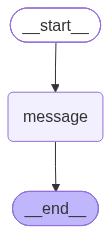

In [15]:
workflow

In [19]:
initial_state = {'question': 'What is the capital of ?'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'What is the capital of ?', 'answer': 'The capital of Ukraine is Kyiv (known in English as Kiev). Kyiv is located in the central part of Ukraine and is the largest city in the country. The city is an important political, economic, and cultural center, and is home to many government institutions, museums, and theaters. Kyiv has a rich history and culture, and is known for its unique architecture, food, and music.'}


In [17]:
while True:
    question = input("Enter your question (or type 'exit' to quit): ")
    if question.strip().lower() in  ['exit', 'quit', 'q']:
        break
    initial_state = {'question': question}
    final_state = workflow.invoke(initial_state)
    print(final_state)

{'question': 'who is the president of uganda', 'answer': "As of my last update in October 2023, the president of Uganda is Yusuf Kabera. However, please note that political leadership can change due to various reasons such as elections, resignations, or shifts in power dynamics. It's always a good idea to verify this information with the latest news or official government sources for the most accurate and up-to-date information."}
{'question': "length of cox's bazar sea beach", 'answer': "The length of Cox's Bazar's sea beach is approximately 14 kilometers."}
